In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import randint, uniform
from sklearn import naive_bayes, linear_model, model_selection, metrics, tree, preprocessing
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, roc_auc_score, roc_curve, auc, precision_score, recall_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics.pairwise import euclidean_distances

import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, Flatten, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import cv2
from scipy.ndimage import gaussian_filter, map_coordinates
from keras.optimizers import Adam, RMSprop
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
import optuna
from optuna.integration import TFKerasPruningCallback

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Input, UpSampling2D
from tensorflow.keras.callbacks import ModelCheckpoint

Loading the dataset <br>
Verifying the CIFAR-10 Data

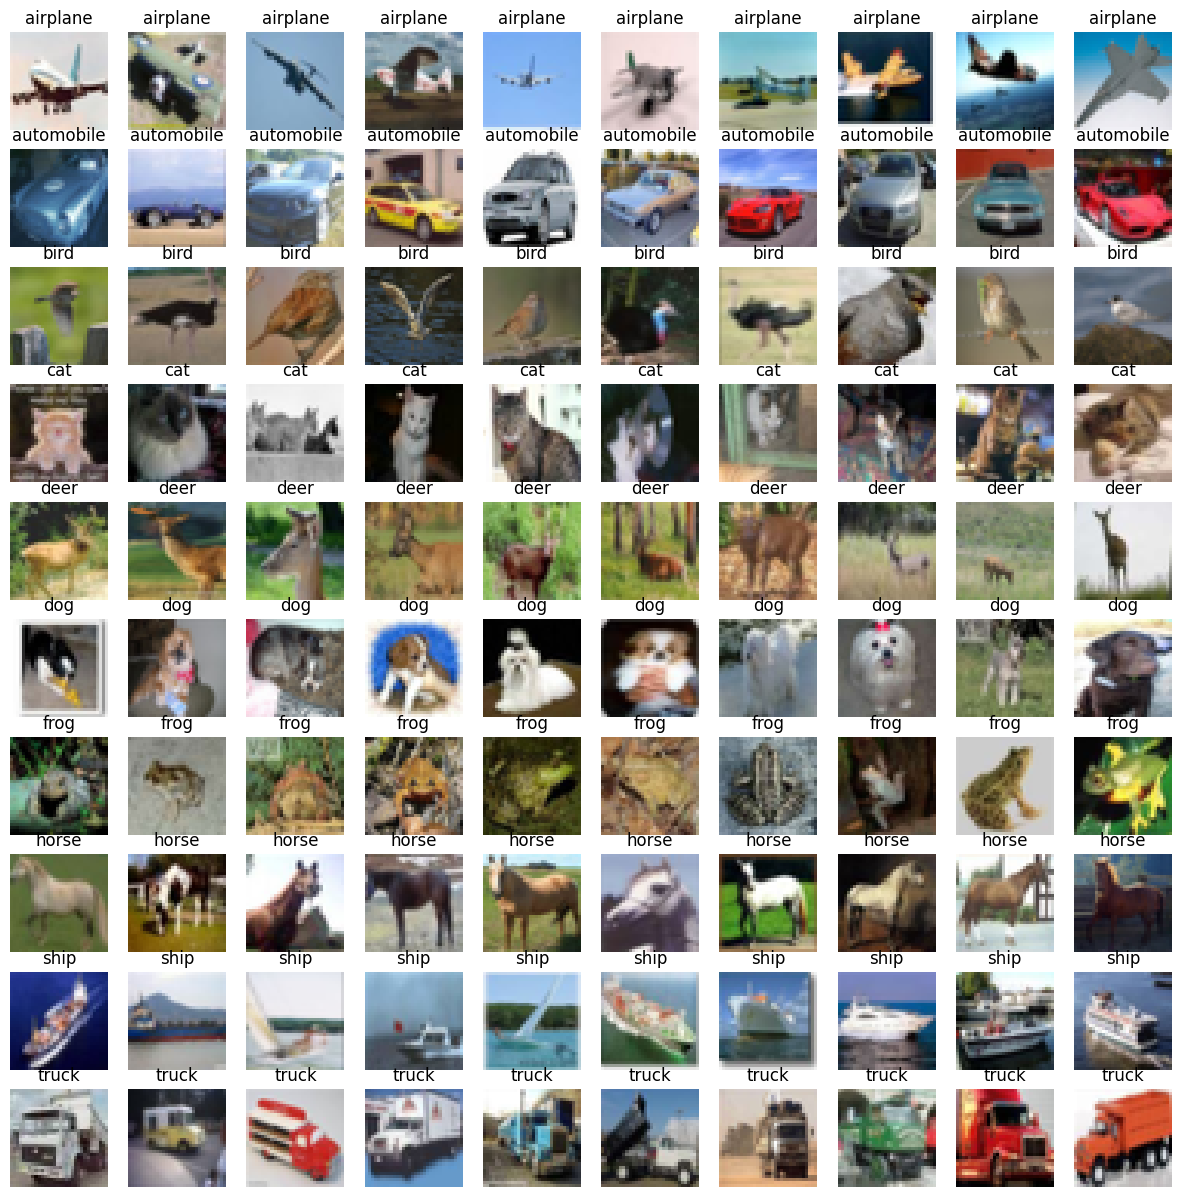

In [4]:
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.cifar10.load_data()
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck'] 
labels = np.unique(train_labels)
final_list = []
name_list = []
labels = np.unique(train_labels)
for label in labels: 
    label_list = list(np.where(train_labels == label)[0]) 
    for iter in range(10): 
        label_index = np.random.choice(tuple(label_list), replace=True) #sampling with replacement
        final_list.append(label_index)
        name_list.append(class_names[int(train_labels[label_index])])
        
fig, ax = plt.subplots(10, 10, figsize=(15,15))
k = 0
for i in range(10):
    for j in range(10):
        ax[i][j].imshow(train_images[final_list[k]])
        ax[i][j].set_title(name_list[k])
        ax[i][j].axis('off')
        k += 1
plt.show()

Normalizing the data

In [5]:
x_train = train_images/255
x_test = test_images/255
y_train_onehot = to_categorical(train_labels)
y_test_onehot = to_categorical(test_labels)

Linear Model

In [ ]:
lin = Sequential()
lin.add(Flatten(input_shape=(32,32,3)))
lin.add(Dense(1000))
lin.add(Dense(10, activation='softmax'))

lin.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

run_lin = lin.fit(x_train, y_train_onehot, epochs=20, validation_data=(x_test, y_test_onehot))

Epoch 1/20
1563/1563 [==============================] - 48s 29ms/step - loss: 2.4207 - accuracy: 0.3003 - val_loss: 1.8783 - val_accuracy: 0.3392
Epoch 2/20
1563/1563 [==============================] - 45s 29ms/step - loss: 1.8844 - accuracy: 0.3347 - val_loss: 1.8860 - val_accuracy: 0.3422
Epoch 3/20
1563/1563 [==============================] - 43s 28ms/step - loss: 1.8924 - accuracy: 0.3349 - val_loss: 1.8733 - val_accuracy: 0.3541
Epoch 4/20
1563/1563 [==============================] - 43s 27ms/step - loss: 1.8896 - accuracy: 0.3399 - val_loss: 1.8776 - val_accuracy: 0.3366
Epoch 5/20
1563/1563 [==============================] - 44s 28ms/step - loss: 1.8719 - accuracy: 0.3471 - val_loss: 1.9153 - val_accuracy: 0.3305
Epoch 6/20
1563/1563 [==============================] - 43s 28ms/step - loss: 1.8607 - accuracy: 0.3529 - val_loss: 1.8328 - val_accuracy: 0.3626
Epoch 7/20
1563/1563 [==============================] - 43s 28ms/step - loss: 1.8565 - accuracy: 0.3571 - val_loss: 1.7879 -

In [ ]:
lin.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 3072)              0         
                                                                 
 dense (Dense)               (None, 1000)              3073000   
                                                                 
 dense_1 (Dense)             (None, 10)                10010     
                                                                 
Total params: 3083010 (11.76 MB)
Trainable params: 3083010 (11.76 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


Confusion Matrix 

313/313 [==============================] - 1s 3ms/step


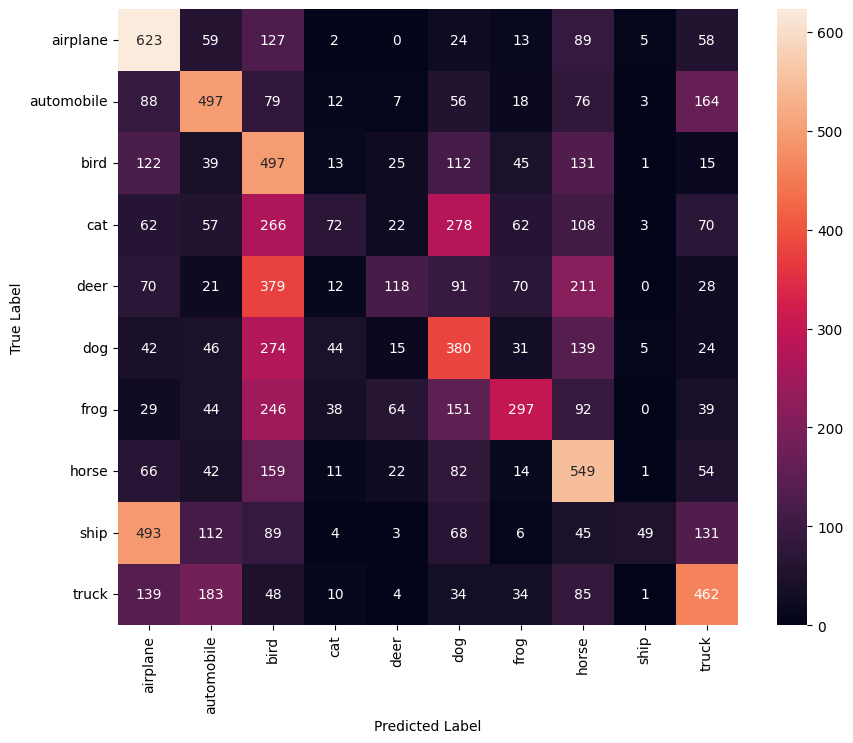

In [ ]:
#predicting on the test set
y_pred_lin = lin.predict(x_test) 

y_pred_lin = np.argmax(y_pred_lin, axis=1)
y_true = np.argmax(y_test_onehot, axis=1)

#confusion matrix
conf_lin = metrics.confusion_matrix(y_true, y_pred_lin)
fig, ax = plt.subplots(figsize=(10, 8))
ax = sns.heatmap(conf_lin, annot=True, fmt='g', xticklabels=class_names, yticklabels=class_names)
ax.set(ylabel="True Label", xlabel="Predicted Label")
plt.show()

Most confused classes would be Airplane and Ship. 

This could be due to the images looking very similar to each other. The general backgrounds of aeroplanes and ships are blue which could also have contributed to the confusion. The outer bodies of ships and planes are also usually desgined in a similar looking manner. 


Classification report and Accuracy Curves

              precision    recall  f1-score   support

           0       0.36      0.62      0.46      1000
           1       0.45      0.50      0.47      1000
           2       0.23      0.50      0.31      1000
           3       0.33      0.07      0.12      1000
           4       0.42      0.12      0.18      1000
           5       0.30      0.38      0.33      1000
           6       0.50      0.30      0.37      1000
           7       0.36      0.55      0.43      1000
           8       0.72      0.05      0.09      1000
           9       0.44      0.46      0.45      1000

    accuracy                           0.35     10000
   macro avg       0.41      0.35      0.32     10000
weighted avg       0.41      0.35      0.32     10000



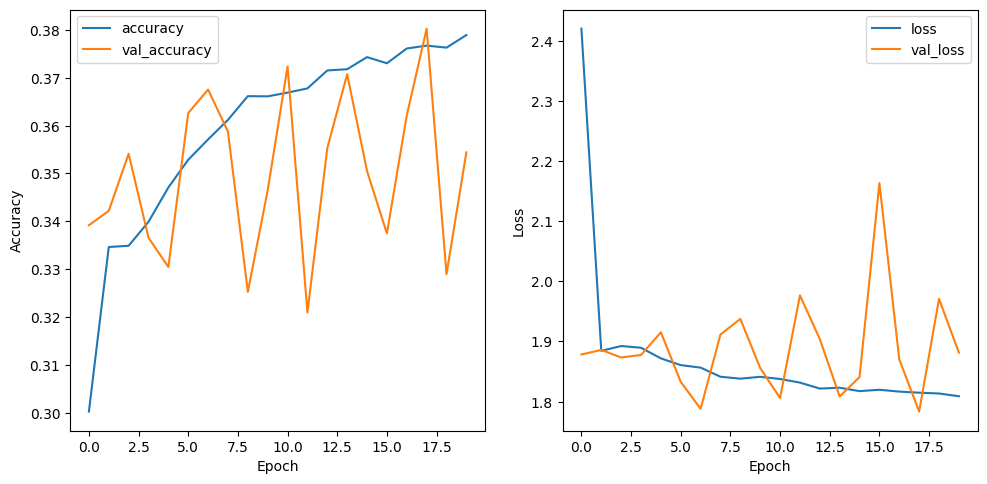

In [ ]:
#Classification report
print(metrics.classification_report(y_true, y_pred_lin))

#Accuracy/loss vs epoch graphs
fig = plt.figure(figsize=(10, 5))
axes1 = fig.add_subplot(1,2,1)
axes2 = fig.add_subplot(1,2,2)
axes1.set(xlabel = 'Epoch', ylabel = 'Accuracy')
axes2.set(xlabel = 'Epoch', ylabel = 'Loss')
fig.tight_layout()
axes1.plot(run_lin.history['accuracy'], label='accuracy')
axes1.plot(run_lin.history['val_accuracy'], label='val_accuracy')
axes1.legend()
axes2.plot(run_lin.history['loss'], label='loss')
axes2.plot(run_lin.history['val_loss'], label='val_loss')
axes2.legend()
plt.show()

Deeper Model with 3 Hidden Layers

In [ ]:
model3h = Sequential()
model3h.add(Flatten(input_shape=(32, 32, 3)))
model3h.add(Dense(512, activation='relu'))
model3h.add(Dense(256, activation='relu'))
model3h.add(Dense(512, activation='relu'))
model3h.add(Dense(10, activation='softmax'))

model3h.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
run_3h = model3h.fit(x_train, y_train_onehot, epochs=20, validation_data=(x_test, y_test_onehot))

Epoch 1/20
1563/1563 [==============================] - 22s 13ms/step - loss: 1.8702 - accuracy: 0.3195 - val_loss: 1.7213 - val_accuracy: 0.3772
Epoch 2/20
1563/1563 [==============================] - 21s 14ms/step - loss: 1.6842 - accuracy: 0.3931 - val_loss: 1.6647 - val_accuracy: 0.4062
Epoch 3/20
1563/1563 [==============================] - 22s 14ms/step - loss: 1.5965 - accuracy: 0.4280 - val_loss: 1.5516 - val_accuracy: 0.4475
Epoch 4/20
1563/1563 [==============================] - 24s 16ms/step - loss: 1.5366 - accuracy: 0.4480 - val_loss: 1.5118 - val_accuracy: 0.4589
Epoch 5/20
1563/1563 [==============================] - 24s 16ms/step - loss: 1.4981 - accuracy: 0.4641 - val_loss: 1.5242 - val_accuracy: 0.4583
Epoch 6/20
1563/1563 [==============================] - 24s 15ms/step - loss: 1.4602 - accuracy: 0.4741 - val_loss: 1.4835 - val_accuracy: 0.4762
Epoch 7/20
1563/1563 [==============================] - 24s 15ms/step - loss: 1.4331 - accuracy: 0.4853 - val_loss: 1.4620 -

In [ ]:
model3h.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_1 (Flatten)         (None, 3072)              0         
                                                                 
 dense_2 (Dense)             (None, 512)               1573376   
                                                                 
 dense_3 (Dense)             (None, 256)               131328    
                                                                 
 dense_4 (Dense)             (None, 512)               131584    
                                                                 
 dense_5 (Dense)             (None, 10)                5130      
                                                                 
Total params: 1841418 (7.02 MB)
Trainable params: 1841418 (7.02 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


Confusion Matrix

313/313 [==============================] - 1s 2ms/step


[Text(95.72222222222221, 0.5, 'True Label'),
 Text(0.5, 58.7222222222222, 'Predicted Label')]

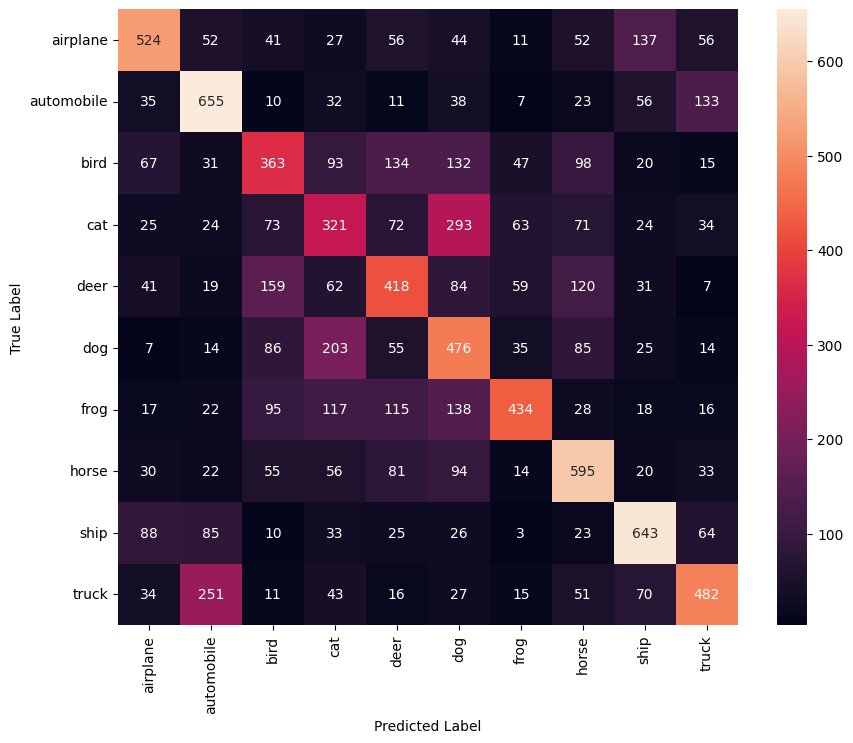

In [ ]:
#predicting on test set
y_pred_h3 = model3h.predict(x_test) 

y_pred_h3 = np.argmax(y_pred_h3, axis=1)
y_true_h3 = np.argmax(y_test_onehot, axis=1)

#confusion matrix
conf_cnn = metrics.confusion_matrix(y_true_h3, y_pred_h3)
fig, ax = plt.subplots(figsize=(10, 8))
ax = sns.heatmap(conf_cnn, annot=True, fmt='g', xticklabels=class_names, yticklabels=class_names)
ax.set(ylabel="True Label", xlabel="Predicted Label")

Comparison with the previous model: The confusion between ships and airplanes seems to be resolved with the deeper model. 
However, there is a slight increase in confusion between trucks and auntomobile, and between cat and dog classes.

There is an improvement in the accuracy of the FNN over the linear model which can be observed in the brighter diagonal of the confusion matrix.

Classification report and Accuracy Curves

              precision    recall  f1-score   support

           0       0.60      0.52      0.56      1000
           1       0.56      0.66      0.60      1000
           2       0.40      0.36      0.38      1000
           3       0.33      0.32      0.32      1000
           4       0.43      0.42      0.42      1000
           5       0.35      0.48      0.40      1000
           6       0.63      0.43      0.51      1000
           7       0.52      0.59      0.55      1000
           8       0.62      0.64      0.63      1000
           9       0.56      0.48      0.52      1000

    accuracy                           0.49     10000
   macro avg       0.50      0.49      0.49     10000
weighted avg       0.50      0.49      0.49     10000



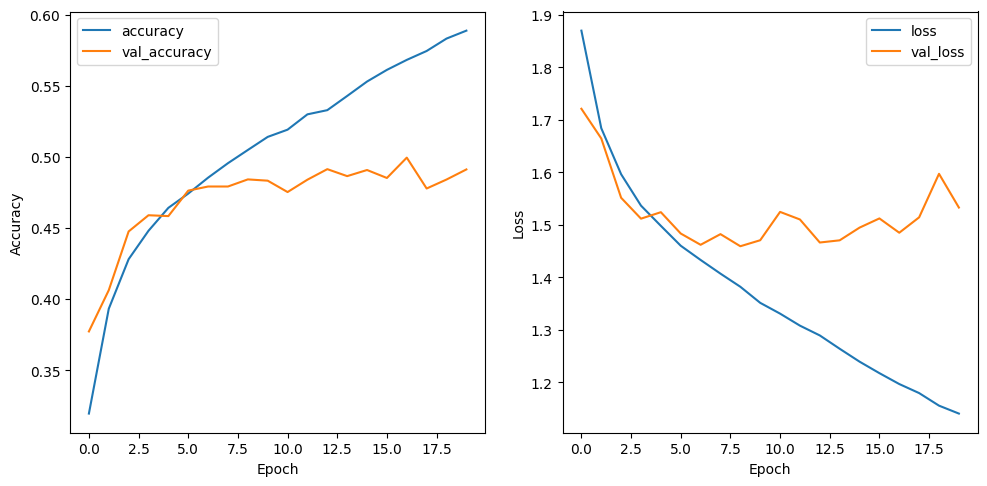

In [ ]:
#classification report
print(metrics.classification_report(y_true, y_pred_h3))

#plotting accuracy graphs against epochs
fig = plt.figure(figsize=(10, 5))
axes1 = fig.add_subplot(1,2,1)
axes2 = fig.add_subplot(1,2,2)
axes1.set(xlabel = 'Epoch', ylabel = 'Accuracy')
axes2.set(xlabel = 'Epoch', ylabel = 'Loss')
fig.tight_layout()
axes1.plot(run_3h.history['accuracy'], label='accuracy')
axes1.plot(run_3h.history['val_accuracy'], label='val_accuracy')
axes1.legend()
axes2.plot(run_3h.history['loss'], label='loss')
axes2.plot(run_3h.history['val_loss'], label='val_loss')
axes2.legend()
plt.show()

Model with 80%+ macro accuracy

In [6]:
INPUT_SHAPE = (32, 32, 3)
KERNEL_SIZE = (3, 3)
model80 = Sequential()

# Convolutional Layer
model80.add(Conv2D(filters=16, kernel_size=KERNEL_SIZE, input_shape=INPUT_SHAPE, activation='relu', padding='same'))
model80.add(BatchNormalization())
model80.add(Conv2D(filters=32, kernel_size=KERNEL_SIZE, input_shape=INPUT_SHAPE, activation='relu', padding='same'))
model80.add(BatchNormalization())
model80.add(MaxPool2D(pool_size=(2, 2)))
model80.add(Dropout(0.25))
model80.add(Conv2D(filters=64, kernel_size=KERNEL_SIZE, input_shape=INPUT_SHAPE, activation='relu', padding='same'))
model80.add(BatchNormalization())
model80.add(MaxPool2D(pool_size=(2, 2)))
model80.add(Dropout(0.25))

model80.add(Flatten())
# model.add(Dropout(0.2))
model80.add(Dense(128, activation='relu'))
model80.add(Dropout(0.25))
model80.add(Dense(10, activation='softmax'))

model80.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
run_80 = model80.fit(x_train, y_train_onehot, epochs=20, validation_data=(x_test, y_test_onehot))

Epoch 1/20
1563/1563 [==============================] - 88s 51ms/step - loss: 1.5636 - accuracy: 0.4372 - val_loss: 1.2078 - val_accuracy: 0.5678
Epoch 2/20
1563/1563 [==============================] - 77s 50ms/step - loss: 1.1769 - accuracy: 0.5822 - val_loss: 1.1097 - val_accuracy: 0.6172
Epoch 3/20
1563/1563 [==============================] - 73s 47ms/step - loss: 1.0422 - accuracy: 0.6339 - val_loss: 1.1364 - val_accuracy: 0.6339
Epoch 4/20
1563/1563 [==============================] - 74s 47ms/step - loss: 0.9551 - accuracy: 0.6661 - val_loss: 0.9216 - val_accuracy: 0.6740
Epoch 5/20
1563/1563 [==============================] - 75s 48ms/step - loss: 0.8877 - accuracy: 0.6894 - val_loss: 0.8330 - val_accuracy: 0.7133
Epoch 6/20
1563/1563 [==============================] - 75s 48ms/step - loss: 0.8205 - accuracy: 0.7138 - val_loss: 0.7986 - val_accuracy: 0.7343
Epoch 7/20
1563/1563 [==============================] - 73s 47ms/step - loss: 0.7730 - accuracy: 0.7306 - val_loss: 0.7408 -

In [7]:
model80.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 32, 32, 16)        448       
                                                                 
 batch_normalization (Batch  (None, 32, 32, 16)        64        
 Normalization)                                                  
                                                                 
 conv2d_1 (Conv2D)           (None, 32, 32, 32)        4640      
                                                                 
 batch_normalization_1 (Bat  (None, 32, 32, 32)        128       
 chNormalization)                                                
                                                                 
 max_pooling2d (MaxPooling2  (None, 16, 16, 32)        0         
 D)                                                              
                                                        

Classification report, Confusion Matrix, Accuracy Curves

313/313 [==============================] - 6s 19ms/step
              precision    recall  f1-score   support

           0       0.90      0.57      0.70      1000
           1       0.93      0.83      0.88      1000
           2       0.60      0.72      0.65      1000
           3       0.57      0.56      0.57      1000
           4       0.74      0.72      0.73      1000
           5       0.57      0.79      0.66      1000
           6       0.81      0.85      0.83      1000
           7       0.92      0.70      0.80      1000
           8       0.85      0.88      0.86      1000
           9       0.81      0.89      0.85      1000

    accuracy                           0.75     10000
   macro avg       0.77      0.75      0.75     10000
weighted avg       0.77      0.75      0.75     10000



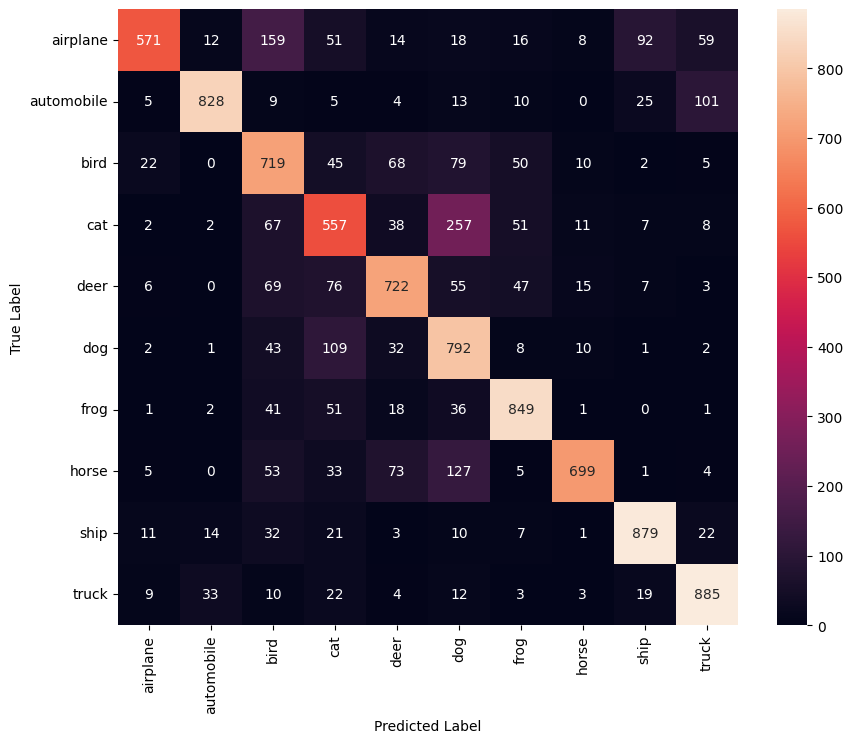

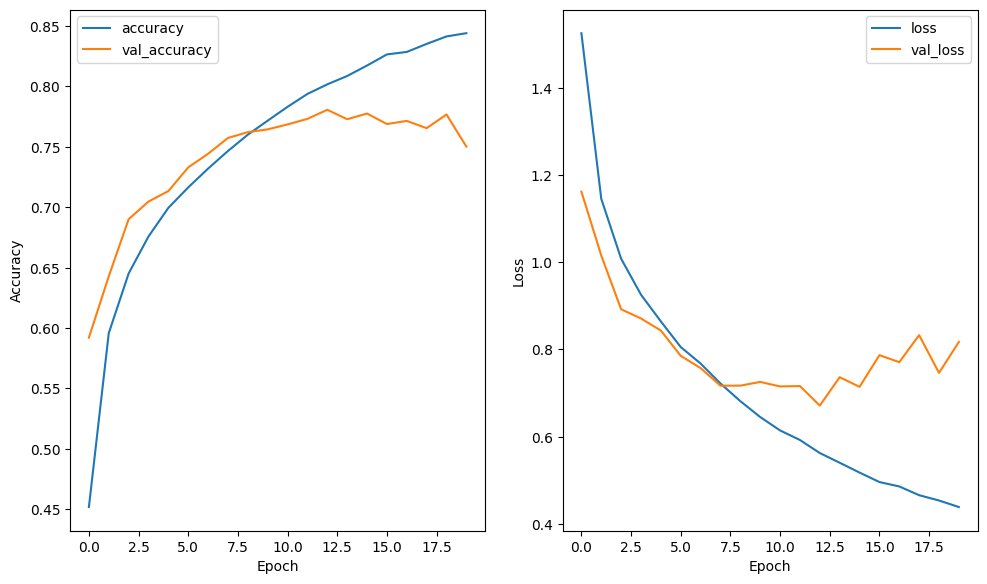

In [ ]:
#predicting on test set
y_pred_80 = model80.predict(x_test) 

y_pred_80 = np.argmax(y_pred_80, axis=1)
y_true_80 = np.argmax(y_test_onehot, axis=1)

#classification report
print(classification_report(y_true, y_pred_80))

#confusion matrix
conf_cnn = confusion_matrix(y_true_80, y_pred_80)
fig, ax = plt.subplots(figsize=(10, 8))
ax = sns.heatmap(conf_cnn, annot=True, fmt='g', xticklabels=class_names, yticklabels=class_names)
ax.set(ylabel="True Label", xlabel="Predicted Label")

#accuracy graphs against epochs
fig = plt.figure(figsize=(10, 6))
axes1 = fig.add_subplot(1,2,1)
axes2 = fig.add_subplot(1,2,2)
axes1.set(xlabel = 'Epoch', ylabel = 'Accuracy')
axes2.set(xlabel = 'Epoch', ylabel = 'Loss')
fig.tight_layout()
axes1.plot(run_80.history['accuracy'], label='accuracy')
axes1.plot(run_80.history['val_accuracy'], label='val_accuracy')
axes1.legend()
axes2.plot(run_80.history['loss'], label='loss')
axes2.plot(run_80.history['val_loss'], label='val_loss')
axes2.legend()
plt.show()

Comparison of CNN with FNN model

Number of trainable parameters in FNN: 1,841,418
Accuracy of FNN: 0.49

Number of trainable parameters in CNN: 554,602
Accuracy of CNN: 0.75

There are lesser trainable parameters in the CNN but higher accuracy.

This could be due to overparameterization of the FNN which caused the model to overfit on the training data.